##### The overarching goal of the portfolio project is to conduct a full analysis of a data set and to build a machine learning model to predict the user churn rate, by following the Plan, Analyse, Construct and Execute methodology (PACE).

# First Stage: Plan

#### Business Task
##### This project aims to identify and predict user churn from the Waze navigation app, through the use of a machine learning model that can accurately predict when users uninstall or stop using the application.

The dataset consists of 1 .csv file, including 13 distinct variables. The data includes information regarding the activity of individual users of the Waze application, such as number of sessions, drives, kilometers driven, and other activity variables, both in total and on a given month.

The data consists of 13 variables: 8 integer variables, 2 string variables, and 3 float variables.

The participants are anonymous and randomized, their PII (personal identifiable information) has been removed and redacted, ensuring that the analysis can be performed without bias. The data has been found to be reliable, original and comprehensive.

Data Dictionary link
https://www.kaggle.com/code/joaofilipemarques/google-advanced-data-analytics-portfolio-project?scriptVersionId=194324224&cellId=3

## Project Scope and Approach¶
The primary objective of this project is to develop a machine learning model capable of accurately predicting user churn rates. By analyzing user data, the model will identify factors contributing to user attrition, enabling Waze to implement targeted strategies to enhance user retention and satisfaction.

The anticipated outcomes of this project include:

##### Assisting the Waze executive team in formulating effective user retention strategies.
##### Enabling the creation of personalized promotional campaigns to address the needs of at-risk users.
##### Providing valuable insights to inform improvements in the user experience.
Essential tools for this phase include Python libraries like Pandas, NumPy, Matplotlib, and Seaborn for data manipulation, analysis, and visualization. Additional libraries for modeling and evaluation will be incorporated in subsequent project stages.

# Importing packages  & Initial EDA

In [2]:
#Data manipulation
import numpy as np
import pandas as pd


In [3]:
#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#statistichs
from scipy import stats
import statsmodels as sm

In [6]:
#Displaying all columns 
pd.set_option("display.max_columns",None)

In [11]:
#Data modelling
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from xgboost import plot_importance

In [8]:
#Metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,\
ConfusionMatrixDisplay,RocCurveDisplay,PrecisionRecallDisplay,classification_report,roc_auc_score,roc_curve,auc,make_scorer

In [9]:
#Warnings
import warnings
warnings.filterwarnings("ignore")

In [10]:
# Load the dataset into dataframe
df=pd.read_csv("waze_dataset.csv")

# Displaying the first few rows of the dataframe
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [12]:
# Gathering basic information about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  str    
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  str    
dtypes: float64(3), int64(8), str(2)
memory usage: 1.5 MB


we see our total data is 14999 but one and only label has 14299 non null values that means label has 14999-142999=700 null values .rest of them have no null values

In [14]:
# check Null values in label columns
df['label'].isnull().sum()

np.int64(700)

# Isolating rows with null values

In [ ]:

null_df=df[pd.isnull(df.label)]
#null_df=df[df['label'].isnull()]#this is 2nd way to filter null rowa both return same result


# Displaying summary stats of rows with null values
null_df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,7405.584286,80.837143,67.798571,198.483348,1709.295714,118.717143,30.371429,3935.967029,1795.123358,15.382857,12.125714
std,4306.900234,79.987440,65.271926,140.561715,1005.306562,156.308140,46.306984,2443.107121,1419.242246,8.772714,7.626373
min,77.000000,0.000000,0.000000,5.582648,16.000000,0.000000,0.000000,290.119811,66.588493,0.000000,0.000000
25%,3744.500000,23.000000,20.000000,94.056340,869.000000,4.000000,0.000000,2119.344818,779.009271,8.000000,6.000000
50%,7443.000000,56.000000,47.500000,177.255925,1650.500000,62.500000,10.000000,3421.156721,1414.966279,15.000000,12.000000
75%,11007.000000,112.250000,94.000000,266.058022,2508.750000,169.250000,43.000000,5166.097373,2443.955404,23.000000,18.000000
max,14993.000000,556.000000,445.000000,1076.879741,3498.000000,1096.000000,352.000000,15135.391280,9746.253023,31.000000,30.000000


Here we can see  count is 700 which is equal to label NaN numbers thats means successfully we filtered all NaN rows

# Isolating rows without null values

In [ ]:
not_null_df=df[~(df['label'].isnull())]#here i get 14299 without null values 
not_null_df.shape

(14299, 13)

In [23]:
# Displaying summary stats of rows without null values
not_null_df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,7503.573117,80.623820,67.255822,189.547409,1751.822505,121.747395,29.638296,4044.401535,1864.199794,15.544653,12.182530
std,4331.207621,80.736502,65.947295,136.189764,1008.663834,147.713428,45.350890,2504.977970,1448.005047,9.016088,7.833835
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000
50%,7504.000000,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000
75%,11257.500000,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


#### Count device on null_df

In [ ]:
null_df['device'].value_counts()#within 700 values of null_df iphone users is 447 and andriod user is 253 

device
iPhone     447
Android    253
Name: count, dtype: int64

#### Calculating percentage of iphone and andriod user in null_df

In [ ]:
null_df['device'].value_counts(normalize=True)#iphone user 63% and andriod user is 37%

device
iPhone     0.638571
Android    0.361429
Name: proportion, dtype: float64

### Calculating percentage of iphone and andriod user in Full dataset

In [26]:
df['device'].value_counts(normalize=True)

device
iPhone     0.644843
Android    0.355157
Name: proportion, dtype: float64

# Calculating counts of churned vs. retained

In [27]:
df['label'].value_counts()

label
retained    11763
churned      2536
Name: count, dtype: int64

# calculating Percentages of churned vs retained users

In [28]:
df['label'].value_counts(normalize=True)

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64

# Calculating median values of all columns for churned and retained users

In [31]:
df.groupby(['label'],as_index=False).median(numeric_only=True)

,label,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
0,churned,7477.5,59.0,50.0,164.339042,1321.0,84.5,11.0,3652.655666,1607.183785,8.0,6.0
1,retained,7509.0,56.0,47.0,157.586756,1843.0,68.0,9.0,3464.684614,1458.046141,17.0,14.0


#### Adding a column to df called `km_per_drive` calculating average km per drive
#### driven_km_drives=total driven_km in one month
#### drives=how many times he drives in a single month 

In [57]:
#average km per drive
df['km_per_drive']=df['driven_km_drives']/df['drives']#.replace(0,np.nan)#here i used replcae cause if drives column has value 0 then and divide drive_km_driver then i get infinity thats why i assign Nan
df['km_per_drive'].head()
df['km_per_drive'].median()


np.float64(74.88006488888888)

In [58]:
df['km_per_drive'].mean()# i remove infinity from 'km_per_drive' now i can calculate mean otherwise it shows infity 

np.float64(inf)

### Grouping by label, calculating the median, and isolating for km per drive

In [59]:
median_km_per_drive_by_label=df.groupby(['label'],as_index=False)['km_per_drive'].median()

In [60]:
# Printing the median km per drive by label
print(median_km_per_drive_by_label)

      label  km_per_drive
0   churned     74.109416
1  retained     75.014702


#### Adding a column to df called `km_per_driving_day` calculating average km per day
#### driven_km_drives=total driven_km in one month
#### driving days=how many days he drives in a single month 

In [65]:
#average km per driving day
df['km_per_driving_days']=df['driven_km_drives']/df['driving_days']#.replace(0,np.nan)#here i used replcae cause if driving_days column has value 0  and divide drive_km_driver then i get infinity thats why i assign Nan
df['km_per_driving_days'].head()
df['km_per_driving_days'].median()

np.float64(323.1459379)

In [66]:
df['km_per_driving_days'].mean()

np.float64(inf)

#### Grouping by label, calculating the median, and isolating for km per driving day

In [67]:
median_km_per_driving_day_by_label=df.groupby(['label'],as_index=False)['km_per_driving_days'].median()

In [68]:
# Printing the median km per driving day by label
print(median_km_per_driving_day_by_label)

      label  km_per_driving_days
0   churned           697.541999
1  retained           289.549333


#### here i see chur user go higher km in a single day comapred to retainded user

##### Adding a column to df called drives_per_driving_day
### calculating how many times average they drive in a single driving day

In [70]:
#calcute average driving occurance in a driving days 
df['drives_per_driving_days']=df['drives']/df['driving_days']

#### Grouping by label, calculating the median, and isolating for drives per driving day

In [71]:
median_drives_per_driving_day_by_label=df.groupby(['label'],as_index=False)['drives_per_driving_days'].median()

In [72]:
# Printing the median drives per driving day by label
print(median_drives_per_driving_day_by_label)

      label  drives_per_driving_days
0   churned                  10.0000
1  retained                   4.0625


#### here i see chur user drive more times in a single driving day comapred to retainded user

# Calculating the number of Android users and iPhone users for each label

In [74]:
number_of_users_per_lebel_by_device=df.groupby(['label'],as_index=False)['device'].value_counts()
number_of_users_per_lebel_by_device

,label,device,count
0,churned,iPhone,1645
1,churned,Android,891
2,retained,iPhone,7580
3,retained,Android,4183


## Calculating the percentage of Android users and iPhone users for each label

In [75]:
percentage_of_users_per_lebel_by_device=df.groupby(['label'])['device'].value_counts(normalize=True)
percentage_of_users_per_lebel_by_device

label     device 
churned   iPhone     0.648659
          Android    0.351341
retained  iPhone     0.644393
          Android    0.355607
Name: proportion, dtype: float64

Both are same no difference on using device 

# EDA Insights

## The analysis revealed that churned users generally had higher drive volumes, driving more frequently and covering longer distances than retained users. No significant differences were observed ## between Android and iPhone users in terms of churn rates.

### The median value was chosen to mitigate the impact of outliers on the results.

# Second Stage: Analyse

# Univariate Analysis
## (uni means one,analyze only ONE variable (column) at a time)
🎯 Purpose:

Understand distribution

Find patterns

Detect outliers

### Creating a box plot of the "sessions" variable.

<Axes: ylabel='sessions'>

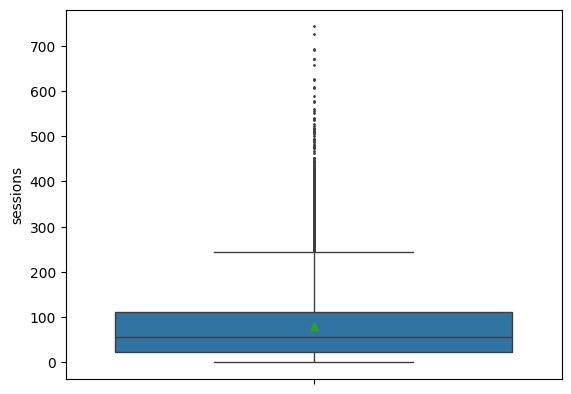

In [80]:
sns.boxplot(
    data=df,
    y='sessions',
    showmeans=True,
    fliersize=1

)

###  Histogram of the "sessions" variable.

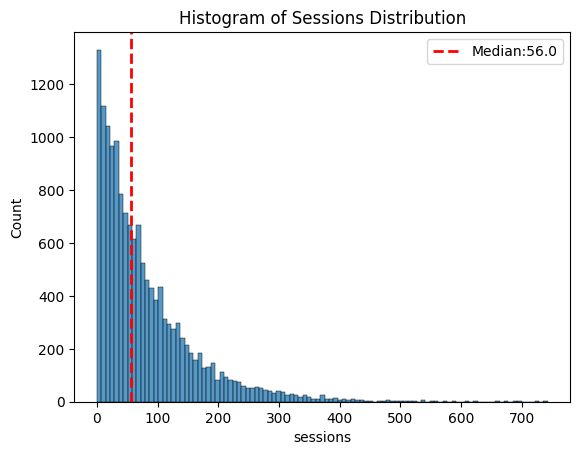

In [84]:
sns.histplot(data=df,x='sessions')
#craeting a quick median calculation
median_sessions=df['sessions'].median()

# Rounding the median value to two decimal places.
median_sessions_rounded=round(median_sessions,2)

# Adding a line for the median.
plt.axvline(x=median_sessions_rounded,color='r',linestyle='dashed',linewidth=2,label="Median:{}".format(median_sessions_rounded))

plt.title("Histogram of Sessions Distribution")
plt.legend()
plt.show()

In [ ]:
df['sessions'].max()#here i see output is 743 and our tail also cross 700 on the right 

np.int64(743)

# Creating a box plot of the "drives" variable.

<Axes: ylabel='drives'>

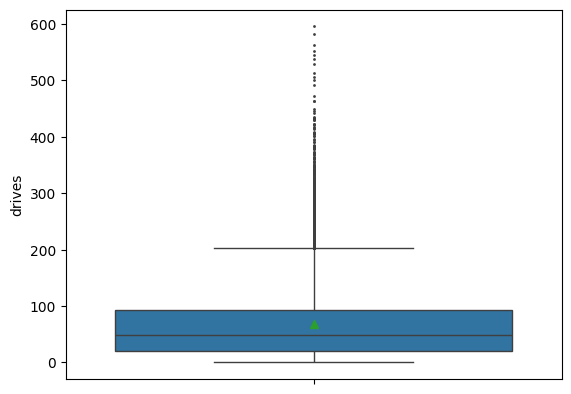

In [85]:
sns.boxplot(
    data=df,
    y='drives',
    showmeans=True,
    fliersize=1
)

# Histogram of the "drives" variable.

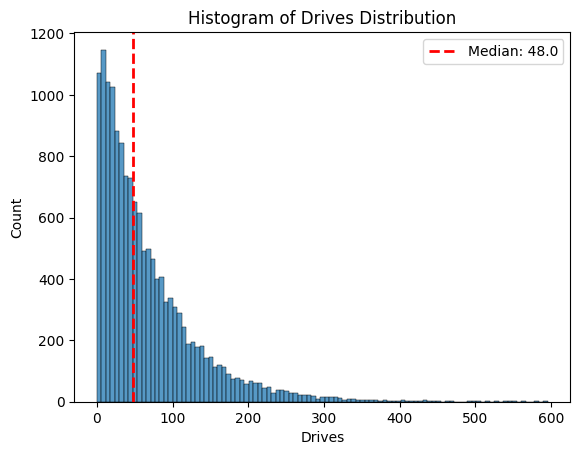

In [86]:
sns.histplot(
    x = "drives",
    data = df
)

# Creating a quick median calculation.
median_drives = df["drives"].median()

# Rounding the median value to two decimal places.
median_drives_rounded = round(median_drives, 2)

# Adding a line for the median.
plt.axvline(x = median_drives, color = "r", linestyle = "dashed", linewidth = 2, label = "Median: {}".format(median_drives_rounded))

# Customising the plot with a title and a label.
plt.title("Histogram of Drives Distribution")
plt.xlabel("Drives")
plt.ylabel("Count")
plt.legend()
plt.show()

In [91]:
df['drives'].max()#here i see output is 596 and our tail also clsoe to 600 

np.int64(596)

# Creating a box plot of the "total_sessions" variable.

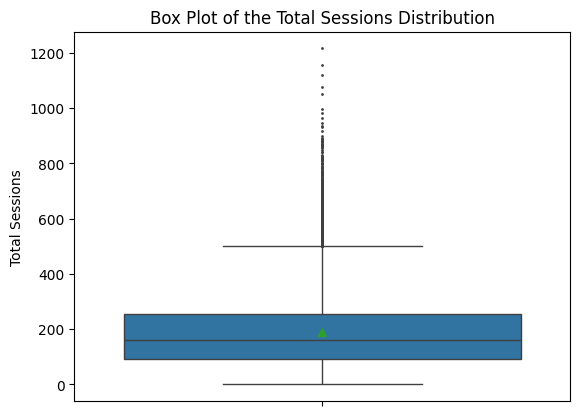

In [92]:
sns.boxplot(
    y = "total_sessions",
    showmeans = True,
    fliersize = 1,
    data = df 
)

# Customising the plot with a title and a label.
plt.title("Box Plot of the Total Sessions Distribution")
plt.ylabel("Total Sessions")
plt.show()

# Histogram of the "total_sessions" variable.

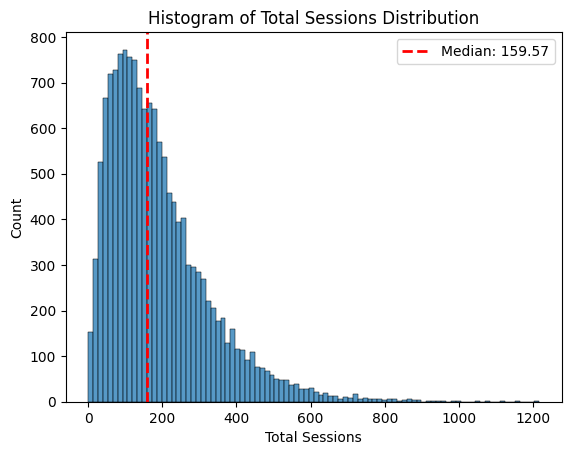

In [93]:
sns.histplot(
    x = "total_sessions",
    data = df
)

# Creating a quick median calculation.
median_total_sessions = df["total_sessions"].median()

# Rounding the median value to two decimal places.
median_total_sessions_rounded = round(median_total_sessions, 2)

# Adding a line for the median.
plt.axvline(x = median_total_sessions, color = "r", linestyle = "dashed", linewidth = 2, label = "Median: {}".format(median_total_sessions_rounded))

# Customising the plot with a title and a label.
plt.title("Histogram of Total Sessions Distribution")
plt.xlabel("Total Sessions")
plt.ylabel("Count")
plt.legend()
plt.show()

In [95]:
df['total_sessions'].max()#here i see output is 1216 and our tail also cross 1200

np.float64(1216.154633)

## Box plot of the "n_days_after_onboarding" variable. user app install করার পর কত দিন হয়েছে

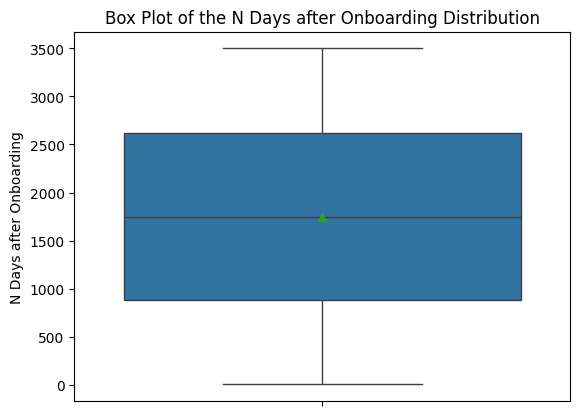

In [96]:
sns.boxplot(
    y = "n_days_after_onboarding",
    showmeans = True,
    fliersize = 1,
    data = df 
)

# Customising the plot with a title and a label.
plt.title("Box Plot of the N Days after Onboarding Distribution")
plt.ylabel("N Days after Onboarding")
plt.show()

## Histogram of the "n_days_after_onboarding" variable.

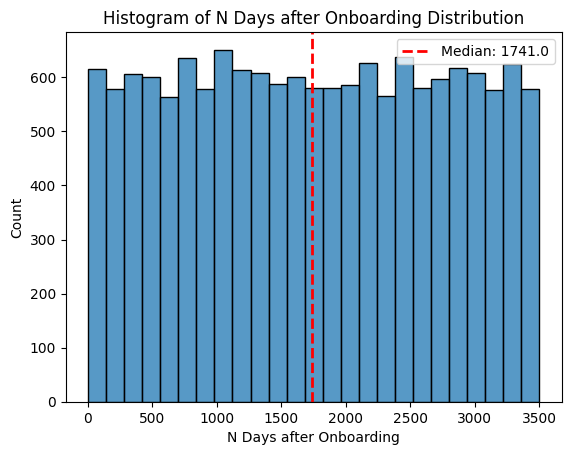

In [97]:
sns.histplot(
    x = "n_days_after_onboarding",
    data = df
)

# Creating a quick median calculation.
median_n_days_after_onboarding = df["n_days_after_onboarding"].median()

# Rounding the median value to two decimal places.
median_n_days_after_onboarding_rounded = round(median_n_days_after_onboarding, 2)

# Adding a line for the median.
plt.axvline(x = median_n_days_after_onboarding, color = "r", linestyle = "dashed", linewidth = 2, label = "Median: {}".format(median_n_days_after_onboarding_rounded))

# Customising the plot with a title and a label.
plt.title("Histogram of N Days after Onboarding Distribution")
plt.xlabel("N Days after Onboarding")
plt.ylabel("Count")
plt.legend()
plt.show()

## Box plot of the "driven_km_drives" variable.

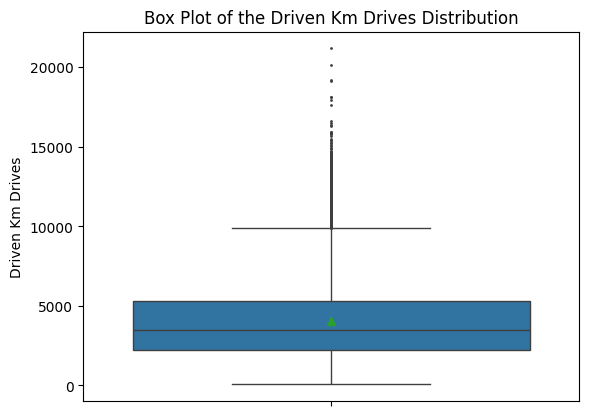

In [98]:
sns.boxplot(
    y = "driven_km_drives",
    showmeans = True,
    fliersize = 1,
    data = df 
)

# Customising the plot with a title and a label.
plt.title("Box Plot of the Driven Km Drives Distribution")
plt.ylabel("Driven Km Drives")
plt.show()

## Histogram of the "driven_km_drives" variable.

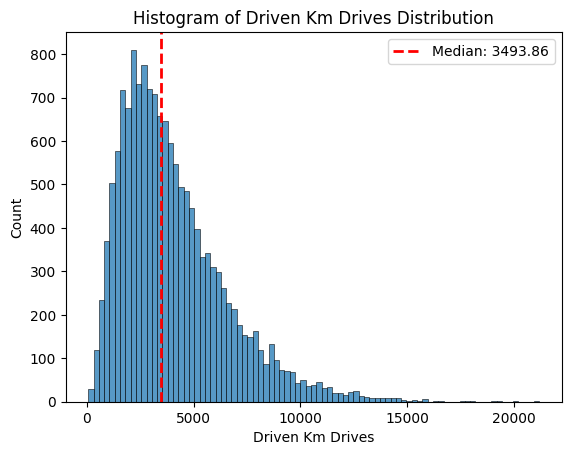

In [99]:
sns.histplot(
    x = "driven_km_drives",
    data = df
)

# Creating a quick median calculation.
median_driven_km_drives = df["driven_km_drives"].median()

# Rounding the median value to two decimal places.
median_driven_km_drives_rounded = round(median_driven_km_drives, 2)

# Adding a line for the median.
plt.axvline(x = median_driven_km_drives, color = "r", linestyle = "dashed", linewidth = 2, label = "Median: {}".format(median_driven_km_drives_rounded))

# Customising the plot with a title and a label.
plt.title("Histogram of Driven Km Drives Distribution")
plt.xlabel("Driven Km Drives")
plt.ylabel("Count")
plt.legend()
plt.show()

## Box plot of the "duration_minutes_drives" variable.

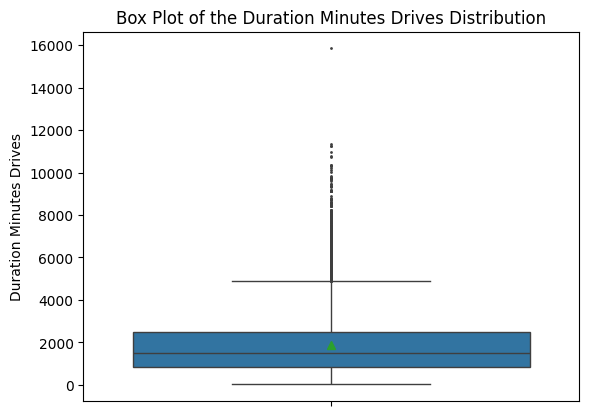

In [100]:
sns.boxplot(
    y = "duration_minutes_drives",
    showmeans = True,
    fliersize = 1,
    data = df 
)

# Customising the plot with a title and a label.
plt.title("Box Plot of the Duration Minutes Drives Distribution")
plt.ylabel("Duration Minutes Drives")
plt.show()

## Histogram of the "driven_km_drives" variable.

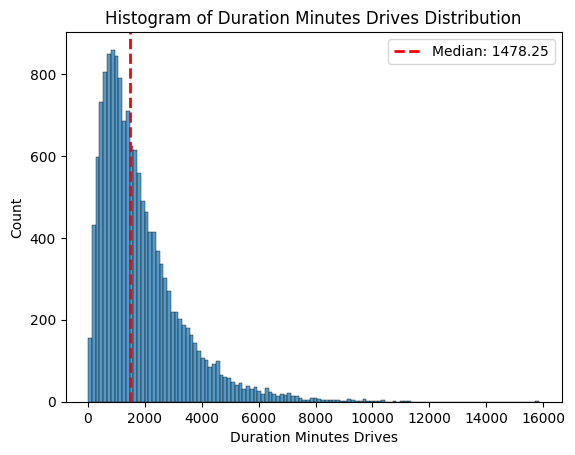

In [101]:
sns.histplot(
    x = "duration_minutes_drives",
    data = df
)

# Creating a quick median calculation.
median_duration_minutes_drives = df["duration_minutes_drives"].median()

# Rounding the median value to two decimal places.
median_duration_minutes_drives_rounded = round(median_duration_minutes_drives, 2)

# Adding a line for the median.
plt.axvline(x = median_duration_minutes_drives, color = "r", linestyle = "dashed", linewidth = 2, label = "Median: {}".format(median_duration_minutes_drives_rounded))

# Customising the plot with a title and a label.
plt.title("Histogram of Duration Minutes Drives Distribution")
plt.xlabel("Duration Minutes Drives")
plt.ylabel("Count")
plt.legend()
plt.show()

# Box plot of the "activity_days" variable.

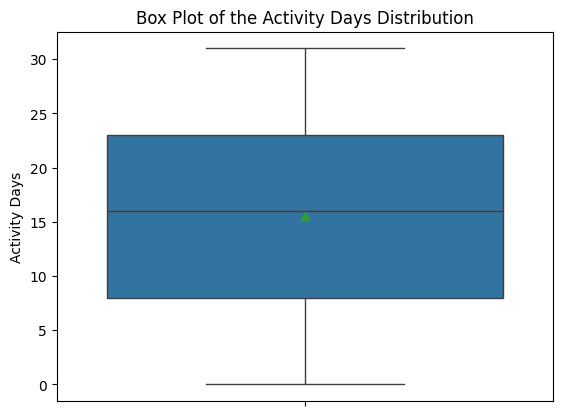

In [102]:
# Box plot of the "activity_days" variable.
sns.boxplot(
    y = "activity_days",
    showmeans = True,
    fliersize = 1,
    data = df 
)

# Customising the plot with a title and a label.
plt.title("Box Plot of the Activity Days Distribution")
plt.ylabel("Activity Days")
plt.show()

# Histogram of the "activity_days" variable.

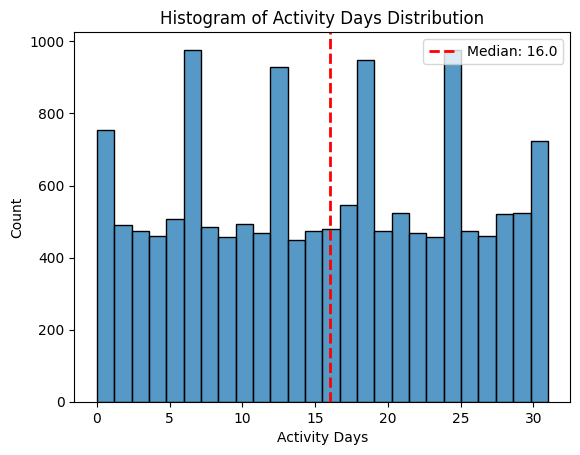

In [103]:

sns.histplot(
    x = "activity_days",
    data = df
)

# Creating a quick median calculation.
median_activity_days = df["activity_days"].median()

# Rounding the median value to two decimal places.
median_activity_days_rounded = round(median_activity_days, 2)

# Adding a line for the median.
plt.axvline(x = median_activity_days, color = "r", linestyle = "dashed", linewidth = 2, label = "Median: {}".format(median_activity_days_rounded))

# Customising the plot with a title and a label.
plt.title("Histogram of Activity Days Distribution")
plt.xlabel("Activity Days")
plt.ylabel("Count")
plt.legend()
plt.show()

# Box plot of the "driving_days" variable.

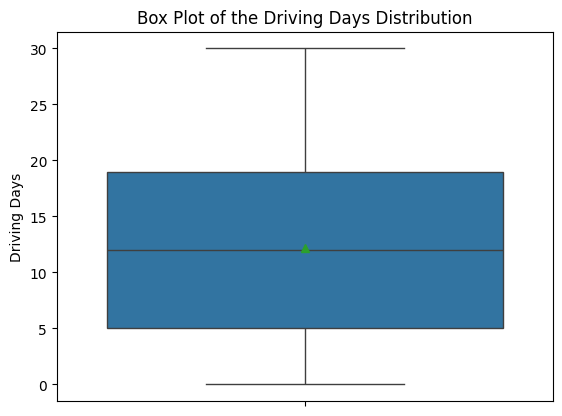

In [104]:
# Box plot of the "driving_days" variable.
sns.boxplot(
    y = "driving_days",
    showmeans = True,
    fliersize = 1,
    data = df 
)

# Customising the plot with a title and a label.
plt.title("Box Plot of the Driving Days Distribution")
plt.ylabel("Driving Days")
plt.show()

# Histogram of the "driving_days" variable.

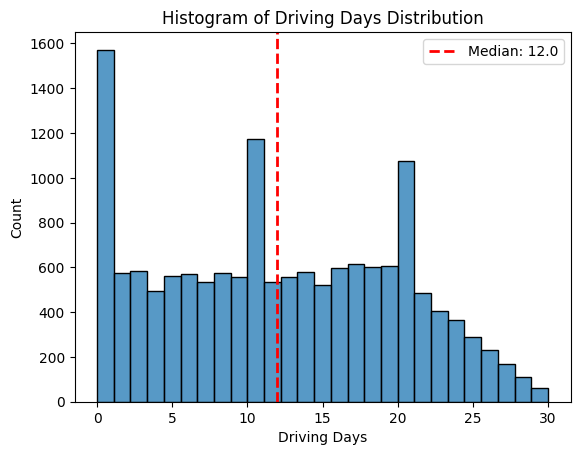

In [105]:

sns.histplot(
    x = "driving_days",
    data = df
)

# Creating a quick median calculation.
median_driving_days = df["driving_days"].median()

# Rounding the median value to two decimal places.
median_driving_days_rounded = round(median_driving_days, 2)

# Adding a line for the median.
plt.axvline(x = median_driving_days, color = "r", linestyle = "dashed", linewidth = 2, label = "Median: {}".format(median_driving_days_rounded))

# Customising the plot with a title and a label.
plt.title("Histogram of Driving Days Distribution")
plt.xlabel("Driving Days")
plt.ylabel("Count")
plt.legend()
plt.show()

# Show percentage of device in the dataset

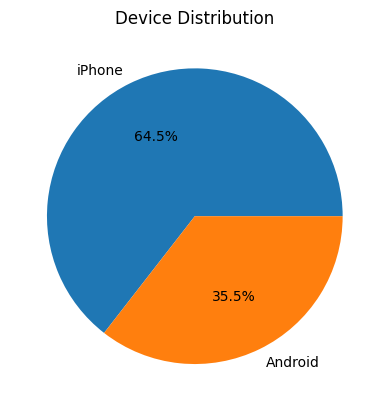

In [107]:
# Obtaining the number of devices
n_device=df['device'].value_counts().sort_values(ascending=False)

# Pie chart of the "device" variable.
plt.pie(n_device,labels=n_device.index,autopct="%1.1f%%")

# Customising the pie chart with a title.
plt.title("Device Distribution")
plt.show()

# Show percentage of labels in the dataset

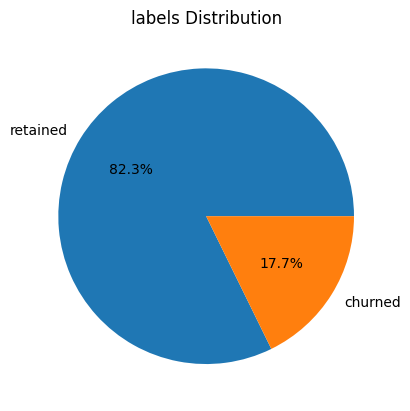

In [109]:
# Obtaining the number of labels
n_label=df['label'].value_counts().sort_values(ascending=False)

# Pie chart of the "labels" variable.
plt.pie(n_label,labels=n_label.index,autopct="%1.1f%%")

# Customising the pie chart with a title.
plt.title("labels Distribution")
plt.show()

# Bivariate Analysis

Meaning:
“Bi” = two ,analyze TWO variables together

## Purpose:
### Find relationship
### Detect correlation
### Compare variables

# Histogram of the "driving days" and "activity_days" variables.

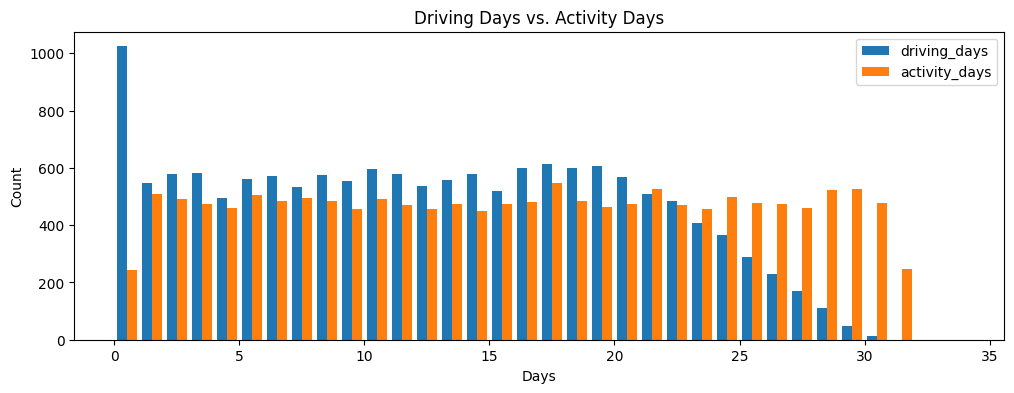

In [110]:
plt.figure(figsize=(12,4))
label=['driving_days','activity_days']

plt.hist([df['driving_days'],df['activity_days']],bins=range(0,35),label=label)
# Customising the histogram with a title, labels and a legend.
plt.xlabel("Days")
plt.ylabel("Count")
plt.legend()
plt.title("Driving Days vs. Activity Days")
plt.show()

This histoplot does not show same row comparison it shows how many times a numbers appears in both driving days and activity days

## Printing the maximum number of days for the variables "driving_days" and "activity_days".

In [113]:
print("Max Driving Days:", df["driving_days"].max())
print("Max Activity Days:", df["activity_days"].max())

Max Driving Days: 30
Max Activity Days: 31


## Scatter plot of the variables "driving_days" and "activity_days".

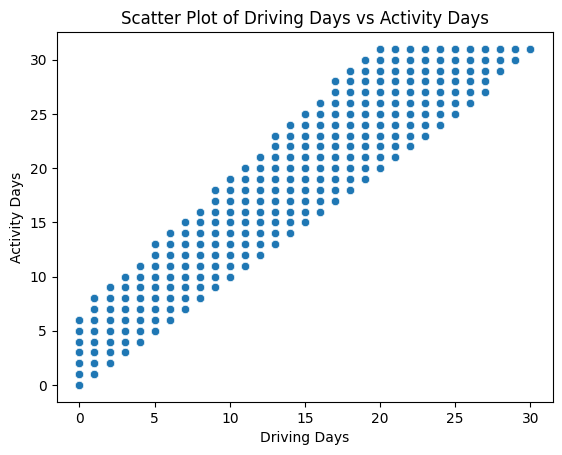

In [114]:
sns.scatterplot(
    x = "driving_days",
    y = "activity_days",
    data = df
)

# Customising the plot with a title and labels
plt.title("Scatter Plot of Driving Days vs Activity Days")
plt.xlabel("Driving Days")
plt.ylabel("Activity Days")
plt.show()

# Here we clearly see driving days always lower than the activity days

## Histogram of the "device" and "label" combination

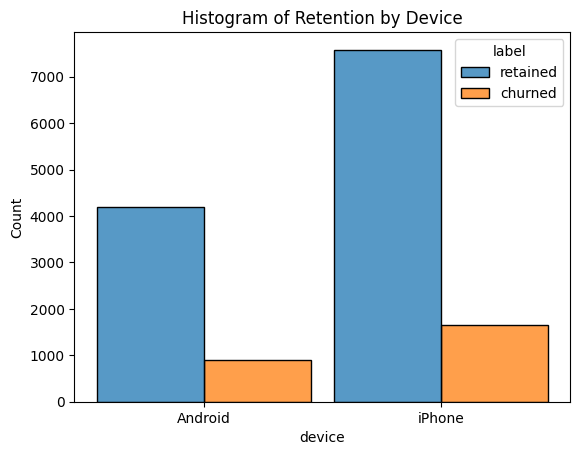

In [121]:
sns.histplot(data=df,x='device',hue='label',multiple='dodge',shrink = 0.9)
# Customising the plot with a title.
plt.title("Histogram of Retention by Device")
plt.show()

### Calling "describe()" on the "km_per_driving_day" column

In [122]:
df['km_per_driving_days'].describe()

count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_days, dtype: float64

### Converting infinite values to zero

In [123]:
# assign 0 inplace of infinity
df.loc[df['km_per_driving_days']==np.inf,'km_per_driving_days']=0

# Confirming that it worked
df['km_per_driving_days'].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_days, dtype: float64

# Multivariate Analysis

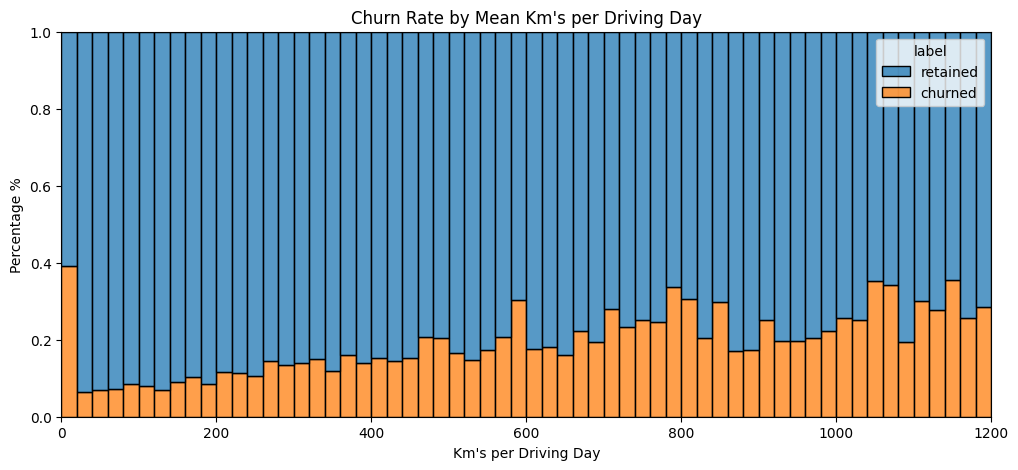

In [464]:
plt.figure(figsize=(12,5))

sns.histplot(data=df,x='km_per_driving_days',bins=range(0,1201,20),hue='label',multiple = "fill")
# Customising the plot with a title and labels.
plt.xlabel("Km's per Driving Day")
plt.ylabel("Percentage %")
plt.title("Churn Rate by Mean Km's per Driving Day")
plt.savefig('Churn_Rate_by_Mean_Kms_per_Driving_Day.png')
plt.show()

A positive correlation was observed between daily driving distance and churn, indicating that users who drove longer distances on a given day were more likely to churn.

## Histogram of the variable "driving_days" and the "label" variable.

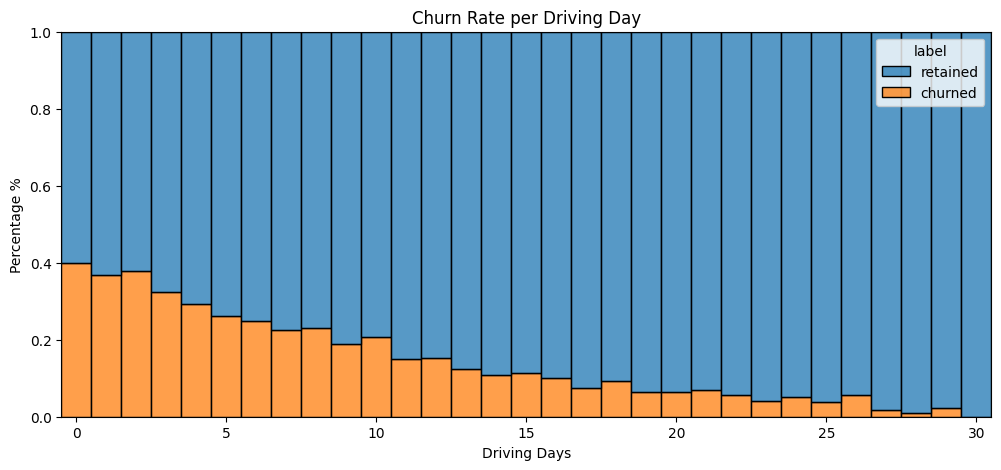

In [465]:
plt.figure(figsize=(12,5))

sns.histplot(
    data=df,
    x='driving_days',
    bins=range(1,32),
    multiple='fill',
    hue='label',
    discrete=True
)
# Customising the plot with a title and labels.
plt.xlabel("Driving Days")
plt.ylabel("Percentage %")
plt.title("Churn Rate per Driving Day")
plt.savefig('Churn_Rate_per_Driving_Day.png')
plt.show()

Conversely, a negative correlation existed between the number of driving days and churn, suggesting that users who drove more frequently were less likely to churn.

## Creating a new column "percent_sessions_in_last_month".

In [136]:
df["percent_sessions_in_last_month"] = df["sessions"] / df["total_sessions"]

In [137]:
# Obtaining the median value of the new column "percent_sessions_in_last_month".
df["percent_sessions_in_last_month"].median()

np.float64(0.42309702992763176)

## Histogram of the "percent_sessions_in_last_month" variable.

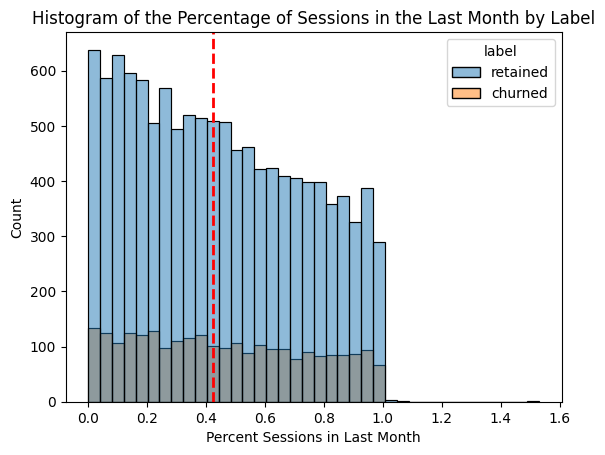

In [140]:
sns.histplot(
    x = "percent_sessions_in_last_month",
    data = df,
    hue = df["label"],
    multiple = "layer",
)

# Assigning a quick median calculation to use in the plot.
median_percent_sessions_in_last_month = df["percent_sessions_in_last_month"].median()

# Adding a line for the median.
plt.axvline(x = median_percent_sessions_in_last_month, color = "r", linestyle = "dashed", linewidth = 2)

# Customising the plot with a title and a label.
plt.title("Histogram of the Percentage of Sessions in the Last Month by Label")
plt.xlabel("Percent Sessions in Last Month")
plt.ylabel("Count")
plt.show()

## Checking the median of the "n_days_after_onboarding" variable.

In [141]:
df["n_days_after_onboarding"].median()

np.float64(1741.0)

### Determining the percentage of people who had 40% or more of their sessions
### in the last month and assigning them to a new dataframe.

In [142]:
df_forty_percent_session_last_month=df.loc[df['percent_sessions_in_last_month']>=0.4]

### Histogram of the "n_days_after_onboarding" variable just for the people 
### who had 40% or more of their sessions in the last month.

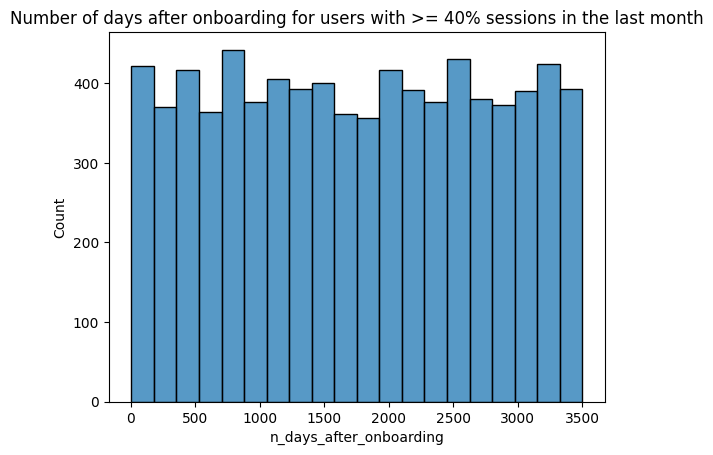

In [144]:
sns.histplot(x=df_forty_percent_session_last_month['n_days_after_onboarding'])
# Customising the plot title.
plt.title("Number of days after onboarding for users with >= 40% sessions in the last month")
plt.show()

## Creating a new column for "monthly_drives_per_session_ratio".

In [145]:
df["monthly_drives_per_session_ratio"] = (df["drives"]/df["sessions"])

In [146]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_drive,km_per_driving_days,drives_per_driving_days,percent_sessions_in_last_month,monthly_drives_per_session_ratio
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,11.632058,138.360267,11.894737,0.953670,0.798587
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone,128.186173,1246.901868,9.727273,0.406856,0.804511
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,32.201567,382.393602,11.875000,0.841186,0.833333
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,22.839778,304.530374,13.333333,0.724968,0.816327
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,58.091206,219.455667,3.777778,0.499266,0.809524


#Hypothesis Testing

In [148]:
map_dictionary={
    'Android':2,
    'iPhone':1
}

In [150]:
df['device_type']=df['device'].map(map_dictionary)
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_drive,km_per_driving_days,drives_per_driving_days,percent_sessions_in_last_month,monthly_drives_per_session_ratio,device_type
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,11.632058,138.360267,11.894737,0.953670,0.798587,2
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone,128.186173,1246.901868,9.727273,0.406856,0.804511,1
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,32.201567,382.393602,11.875000,0.841186,0.833333,2
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,22.839778,304.530374,13.333333,0.724968,0.816327,1
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,58.091206,219.455667,3.777778,0.499266,0.809524,2


## Grouping average drives by device type

In [151]:
df.groupby(['device_type'])['drives'].mean()

device_type
1    67.859078
2    66.231838
Name: drives, dtype: float64

Hypothesis Test Details

Type of test: T-test for two independent samples.

Null Hypothesis (H0): There is no statistically significant difference between the mean number of drives for each device.

Alternative Hypothesis (HA): There is a statistically significant difference between the mean number of drives for each device.

Significance Level: 5%

# Isolate 'drives' column for iphone and andiod

In [156]:
# iphone=df[df['device_type']==1]['drives']
iphone=df.loc[df['device_type']==1,'drives']
andriod=df.loc[df['device_type']==2,'drives']

## Performing t-test

In [157]:
stats.ttest_ind(a=iphone,b=andriod,equal_var=False)

TtestResult(statistic=np.float64(1.463523206885235), pvalue=np.float64(0.143351972680206), df=np.float64(11345.066049381952))

Hypothesis Test Result

A P-value of 0.14 was obtained, or 14%, which means the P-value is greater than the significance level of 5%, as such we fail to reject the null hypothesis and conclude that there is indeed no statistically meaningful difference between the average amount of rides per device type.

# Analysis Insights
Histograms revealed that most variables were right-skewed, while some exhibited uniform distribution. While a few outliers were observed, the data generally appeared to be of high quality, with no significant issues affecting variables like driven_km_drives.

An anomaly was noted in the activity_days and driving_days variables, with maximum values of 31 and 30 respectively, suggesting potential data discrepancies related to the months represented. Further investigation is necessary to determine if these variables correspond to different months and to identify any underlying reasons for the unusually high user activity during the final month.

The analysis found a churn rate of 18%, with 82% of users remaining retained. A positive correlation was observed between daily driving distance and churn, indicating that users who drove longer distances on a given day were more likely to churn. Conversely, a negative correlation existed between the number of driving days and churn, suggesting that users who drove more frequently were less likely to churn.

Regarding user tenure, the distribution of days since onboarding was relatively uniform, indicating that user longevity did not significantly impact churn rates.

Finally, the hypothesis test concludes that there is no statistically significant difference between the average amount of rides per device used by the user.

# Third Stage: Construct

In [158]:
df1=pd.read_csv("waze_dataset.csv")
df1.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


# Dropping the ID variable

In [159]:
df1=df1.drop('ID',axis=1)

## Checking the class balance of the target variable

In [161]:
df1['label'].value_counts(normalize=True)

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64

In [162]:
# Calling describe on the new dataset
df1.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


## Feature Engineering

In [163]:
# Recreating necessary features
df1['km_per_driving_day']=df1['driven_km_drives']/df1['driving_days']

# Calling describe() on the new column
df1["km_per_driving_day"].describe()

count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

In [165]:
# Converting infinite values to zero
df1.loc[df1["km_per_driving_day"] == np.inf, "km_per_driving_day"] = 0

# Confirming that it worked
df1["km_per_driving_day"].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

## Creating a professional_driver column

In [166]:
def is_professional(row):
    drives=row['drives']
    driving_days=row['driving_days']
    return (drives>=60) & (driving_days>=15)

df1['professional_driver']=df1.apply(is_professional,axis=1)

In [168]:
df1.head()

,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_driving_day,professional_driver
0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,138.360267,True
1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone,1246.901868,False
2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,382.393602,False
3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,304.530374,False
4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,219.455667,True


## Checking the count of professionals and non-professionals

In [171]:
n_professional_drivers=df1[df1['professional_driver']==True].shape[0]
n_non_professional_drivers=df1[df1['professional_driver']==False].shape[0]
print(n_professional_drivers,n_non_professional_drivers)

2594 12405


In [177]:
professional_driver_churn_rate=df1[df1['professional_driver']==True]['label'].value_counts(normalize=True)['churned']
non_professional_driver_churn_rate=df1[df1['professional_driver']==False]['label'].value_counts(normalize=True)['churned']

In [178]:
# Printing the results
print("Number of Professional Drivers:", n_professional_drivers)
print("Number of Non-Professional Drivers:", n_non_professional_drivers)
print("Churn Rate (Professional Drivers):", professional_driver_churn_rate)
print("Churn Rate (Non-Professional Drivers):", non_professional_driver_churn_rate)

Number of Professional Drivers: 2594
Number of Non-Professional Drivers: 12405
Churn Rate (Professional Drivers): 0.07556270096463022
Churn Rate (Non-Professional Drivers): 0.19879773092879519


We see churn is high on no professional driver

In [179]:
# Calling info on the dataframe
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   label                    14299 non-null  str    
 1   sessions                 14999 non-null  int64  
 2   drives                   14999 non-null  int64  
 3   total_sessions           14999 non-null  float64
 4   n_days_after_onboarding  14999 non-null  int64  
 5   total_navigations_fav1   14999 non-null  int64  
 6   total_navigations_fav2   14999 non-null  int64  
 7   driven_km_drives         14999 non-null  float64
 8   duration_minutes_drives  14999 non-null  float64
 9   activity_days            14999 non-null  int64  
 10  driving_days             14999 non-null  int64  
 11  device                   14999 non-null  str    
 12  km_per_driving_day       14999 non-null  float64
 13  professional_driver      14999 non-null  bool   
dtypes: bool(1), float64(4), int64(7),

## Dropping rows with missing data in label column

In [182]:
df1=df1.dropna(subset=['label'])#remove 200 rows which was null in label column


In [183]:
df1.info()

<class 'pandas.DataFrame'>
Index: 14299 entries, 0 to 14998
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   label                    14299 non-null  str    
 1   sessions                 14299 non-null  int64  
 2   drives                   14299 non-null  int64  
 3   total_sessions           14299 non-null  float64
 4   n_days_after_onboarding  14299 non-null  int64  
 5   total_navigations_fav1   14299 non-null  int64  
 6   total_navigations_fav2   14299 non-null  int64  
 7   driven_km_drives         14299 non-null  float64
 8   duration_minutes_drives  14299 non-null  float64
 9   activity_days            14299 non-null  int64  
 10  driving_days             14299 non-null  int64  
 11  device                   14299 non-null  str    
 12  km_per_driving_day       14299 non-null  float64
 13  professional_driver      14299 non-null  bool   
dtypes: bool(1), float64(4), int64(7), str(

## Imputing outliers

In [184]:
cols_with_outliers = ["sessions", "drives", "total_sessions", 
                     "total_navigations_fav1", "total_navigations_fav2", 
                     "driven_km_drives", "duration_minutes_drives"]

In [185]:
def cap_outliers(df1,col):
    percentile_value=df1[col].quantile(0.95)
    df1.loc[df1[col]>percentile_value,col]=percentile_value
    return df1

for col in cols_with_outliers:
    df1=cap_outliers(df1.copy(),col)

In [186]:
df1

,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_driving_day,professional_driver
0,retained,243,200,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,138.360267,True
1,retained,133,107,326.896596,1225,19,64,8898.716275,3160.472914,13,11,iPhone,1246.901868,False
2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,382.393602,False
3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,304.530374,False
4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,219.455667,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,retained,60,55,207.875622,140,317,0,2890.496901,2186.155708,25,17,iPhone,170.029229,False
14995,retained,42,35,187.670313,2505,15,10,4062.575194,1208.583193,25,20,Android,203.128760,False
14996,retained,243,200,422.017241,1873,17,0,3097.825028,1031.278706,18,17,iPhone,182.225002,True
14997,churned,149,120,180.524184,3150,45,0,4051.758549,254.187763,6,6,iPhone,675.293092,False


In [187]:
df1.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,76.539688,63.964683,183.717304,1751.822505,114.562767,27.187216,3944.558631,1792.911210,15.544653,12.182530,581.942399
std,67.243178,55.127927,118.720520,1008.663834,124.378550,36.715302,2218.358258,1224.329759,9.016088,7.833835,1038.254509
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,0.000000
25%,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000,136.168003
50%,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000,273.301012
75%,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000,558.018761
max,243.000000,200.000000,455.439492,3500.000000,422.000000,124.000000,8898.716275,4668.180092,31.000000,30.000000,15420.234110


# Encoding variables

In [192]:
df1['label2']=df1['label'].apply(lambda x: 0 if x=="retained" else 1)
df1['device2']=df1['device'].apply(lambda x: 0 if x=="Android" else 1)

In [193]:
df1.head(20)

,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_driving_day,professional_driver,label2,device2
0,retained,243,200,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,138.360267,True,0,0
1,retained,133,107,326.896596,1225,19,64,8898.716275,3160.472914,13,11,iPhone,1246.901868,False,0,1
2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,382.393602,False,0,0
3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,304.530374,False,0,1
4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,219.455667,True,0,0
5,retained,113,103,279.544437,2637,0,0,901.238699,439.101397,15,11,iPhone,81.930791,False,0,1
6,retained,3,2,236.725314,360,185,18,5249.172828,726.577205,28,23,iPhone,228.224906,False,0,1
7,retained,39,35,176.072845,2999,0,0,7892.052468,2466.981741,22,20,iPhone,394.602623,False,0,1
8,retained,57,46,183.532018,424,0,26,2651.709764,1594.342984,25,20,Android,132.585488,False,0,0
9,churned,84,68,244.802115,2997,72,0,6043.460295,2341.838528,7,3,iPhone,2014.486765,False,1,1


# Model Assumptions

In [194]:
# Generating a correlation matrix
correlation_matrix=df1.corr(method='pearson',numeric_only=True)
correlation_matrix

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,professional_driver,label2,device2
sessions,1.000000,0.996942,0.597189,0.007101,0.001858,0.008536,0.002996,-0.004545,0.025113,0.020294,-0.011569,0.443654,0.034911,0.012704
drives,0.996942,1.000000,0.595285,0.006940,0.001058,0.009505,0.003445,-0.003889,0.024357,0.019608,-0.010989,0.444425,0.035865,0.011684
total_sessions,0.597189,0.595285,1.000000,0.006596,0.000187,0.010371,0.001016,-0.000338,0.015755,0.012953,-0.016167,0.254433,0.024568,0.012138
n_days_after_onboarding,0.007101,0.006940,0.006596,1.000000,-0.002450,-0.004968,-0.004652,-0.010167,-0.009418,-0.007321,0.011764,0.003770,-0.129263,-0.011299
total_navigations_fav1,0.001858,0.001058,0.000187,-0.002450,1.000000,0.002866,-0.007368,0.005646,0.010902,0.010419,-0.000197,-0.000224,0.052322,-0.001316
total_navigations_fav2,0.008536,0.009505,0.010371,-0.004968,0.002866,1.000000,0.003559,-0.003009,-0.004425,0.002000,0.006751,0.007126,0.015032,-0.000275
driven_km_drives,0.002996,0.003445,0.001016,-0.004652,-0.007368,0.003559,1.000000,0.690515,-0.007441,-0.009549,0.344811,-0.000904,0.019767,-0.002091
duration_minutes_drives,-0.004545,-0.003889,-0.000338,-0.010167,0.005646,-0.003009,0.690515,1.000000,-0.007895,-0.009425,0.239627,-0.012128,0.040407,-0.007709
activity_days,0.025113,0.024357,0.015755,-0.009418,0.010902,-0.004425,-0.007441,-0.007895,1.000000,0.947687,-0.397433,0.453825,-0.303851,-0.010221
driving_days,0.020294,0.019608,0.012953,-0.007321,0.010419,0.002000,-0.009549,-0.009425,0.947687,1.000000,-0.407917,0.469776,-0.294259,-0.003859


#  Plotting a correlation heatmap

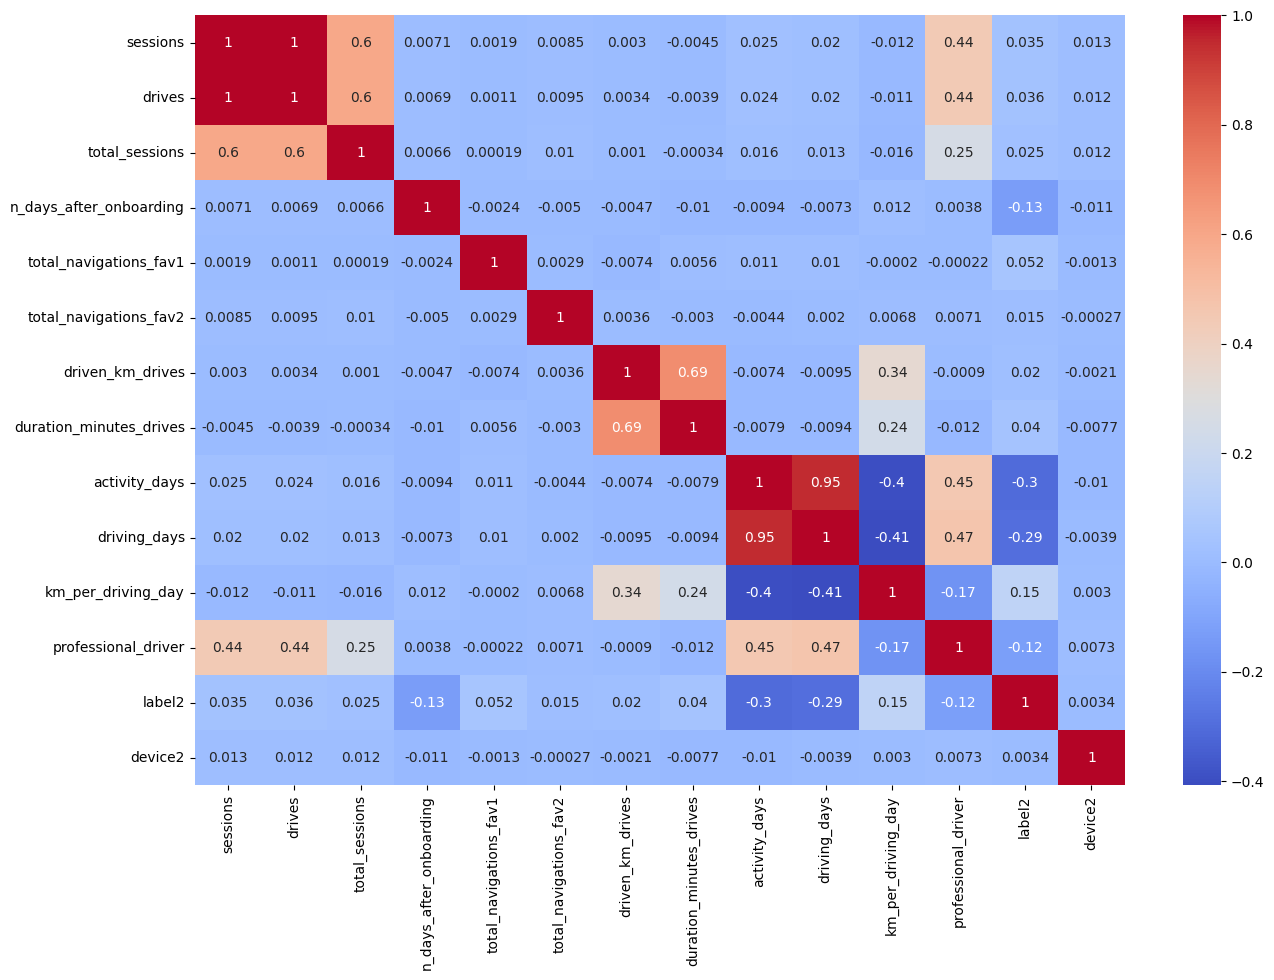

In [196]:
plt.figure(figsize=(15,10))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.show()

# Isolating predictor variables

In [198]:
cols_to_drop = ["label", "label2", "device", "sessions", "driving_days"]
x=df1.drop(cols_to_drop,axis=1)

# Isolating target variable
y=df1['label2']

In [202]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,stratify=y)#stratify মানে হলো data split করার সময় class ratio একই রাখা

In [203]:
x_train.head()

,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,km_per_driving_day,professional_driver,device2
152,108,186.192746,3116,243,124,8898.716275,4668.180092,24,612.305861,True,1
11899,2,3.487590,794,114,18,3286.545691,1780.902733,5,3286.545691,False,1
10937,139,347.106403,331,4,7,7400.838975,2349.305267,15,616.736581,False,0
669,108,455.439492,2320,11,4,6566.424830,4558.459870,18,410.401552,True,1
8406,10,89.475821,2478,135,0,1271.248661,938.711572,27,74.779333,False,1


# Instatiating the logistic regression model

In [214]:
model=LogisticRegression(penalty="l2",max_iter=400)
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

# Obtaining the coefficients of each variable

In [216]:
coefficients=model.coef_.squeeze()#squeeze convert 2d to 1d data
feature_name=x_train.columns
coefficients_series=pd.Series(coefficients,index=feature_name)
print(coefficients_series)

drives                     0.001939
total_sessions             0.000359
n_days_after_onboarding   -0.000401
total_navigations_fav1     0.001252
total_navigations_fav2     0.000990
driven_km_drives          -0.000013
duration_minutes_drives    0.000110
activity_days             -0.105320
km_per_driving_day         0.000019
professional_driver       -0.007513
device2                    0.022878
dtype: float64


In [217]:
model.intercept_

array([-0.05766764])

## Getting the predicted probabilities of the training data

In [218]:
y_train_proba=model.predict_proba(x_train)
y_train_proba

array([[0.93743651, 0.06256349],
       [0.62185353, 0.37814647],
       [0.76667847, 0.23332153],
       ...,
       [0.91809129, 0.08190871],
       [0.84887242, 0.15112758],
       [0.93336771, 0.06663229]], shape=(10724, 2))

## Copying the X_train dataframe and assigning to logit_data

In [219]:
logit_data=x_train.copy()
logit_data['logit']=[np.log(prob[1]/prob[0]) for prob in y_train_proba]

In [220]:
logit_data['logit']

152     -2.706967
11899   -0.497423
10937   -1.189650
669     -2.054161
8406    -3.564131
           ...   
13365   -0.286548
8232    -3.496697
1556    -2.416691
2893    -1.725785
13140   -2.639610
Name: logit, Length: 10724, dtype: float64

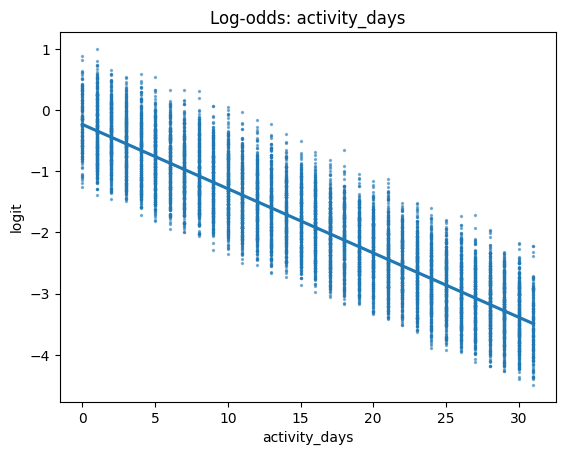

In [ ]:
# Plotting regplot of activity_days log-odds
sns.regplot(x = "activity_days", y = "logit", data = logit_data, scatter_kws = {"s": 2, "alpha": 0.5})
plt.title("Log-odds: activity_days")

In [223]:
# Generating predictions on X_test
y_pred = model.predict(x_test)

In [224]:
# Scoring the model (accuracy) on the test data
model.score(x_test, y_test)

0.8243356643356643

# Generating a classification report

In [225]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.98      0.90      2941
           1       0.53      0.09      0.16       634

    accuracy                           0.82      3575
   macro avg       0.68      0.54      0.53      3575
weighted avg       0.78      0.82      0.77      3575



The logistic regression model exhibited poor performance, achieving an accuracy of 82%. The precision and recall scores of 52%, and 9% respectively indicate that the model does not suit the business adequately. The F1-score of 16% suggests that the model cannot correctly predict both positive and negative cases.

# Generating a confusion matrix

In [226]:
cm = confusion_matrix(y_test, y_pred)

### Displaying the confusion matrix

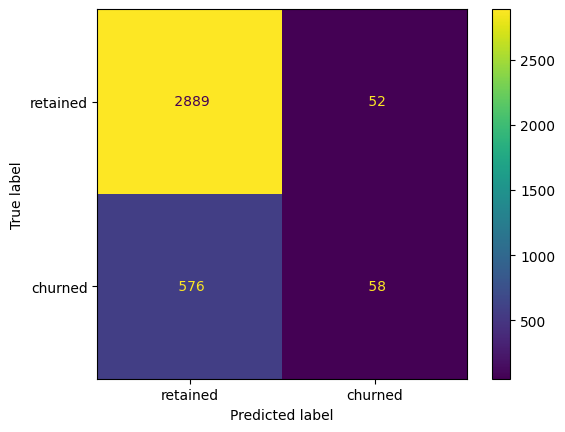

In [228]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['retained','churned'])
disp.plot(values_format=" ")

In [233]:
# Creating a list of (column_name, coefficient) tuples
feature_importance=list(zip(x_train.columns,model.coef_[0]))
feature_importance

[('drives', np.float64(0.0019392288625766018)),
 ('total_sessions', np.float64(0.00035875571393744675)),
 ('n_days_after_onboarding', np.float64(-0.00040133662710929973)),
 ('total_navigations_fav1', np.float64(0.001252345439324352)),
 ('total_navigations_fav2', np.float64(0.0009901120275883283)),
 ('driven_km_drives', np.float64(-1.2928981675162743e-05)),
 ('duration_minutes_drives', np.float64(0.00010999605821195442)),
 ('activity_days', np.float64(-0.10532042939511342)),
 ('km_per_driving_day', np.float64(1.9324434765894818e-05)),
 ('professional_driver', np.float64(-0.007512902985353698)),
 ('device2', np.float64(0.022877805187454935))]

In [234]:
# Sorting the list by coefficient value
feature_importance = sorted(feature_importance, key = lambda x: x[1], reverse = True)
feature_importance

[('device2', np.float64(0.022877805187454935)),
 ('drives', np.float64(0.0019392288625766018)),
 ('total_navigations_fav1', np.float64(0.001252345439324352)),
 ('total_navigations_fav2', np.float64(0.0009901120275883283)),
 ('total_sessions', np.float64(0.00035875571393744675)),
 ('duration_minutes_drives', np.float64(0.00010999605821195442)),
 ('km_per_driving_day', np.float64(1.9324434765894818e-05)),
 ('driven_km_drives', np.float64(-1.2928981675162743e-05)),
 ('n_days_after_onboarding', np.float64(-0.00040133662710929973)),
 ('professional_driver', np.float64(-0.007512902985353698)),
 ('activity_days', np.float64(-0.10532042939511342))]

# Plotting the feature importances for Logistic Regression

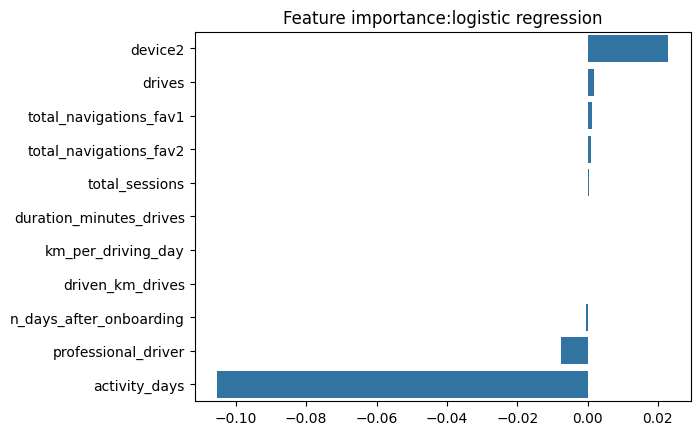

In [462]:
sns.barplot(
    x=[x[1] for x in feature_importance],
    y=[x[0] for x in feature_importance],
    orient='h'
)
plt.title("Feature importance:logistic regression");
plt.savefig('logistic_feature_importance')

# implemented scalling but did not improve accuracy


In [251]:
temp_x=x
temp_x

,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,km_per_driving_day,professional_driver,device2
0,200,0.651396,0.649886,208,0,0.290600,0.423126,28,0.008973,True,0
1,107,0.717624,0.349256,19,64,1.000000,0.675755,13,0.080861,False,1
2,95,0.297225,0.757151,0,0,0.339287,0.342471,14,0.024798,False,0
3,40,0.147992,0.003146,322,7,0.096529,0.122350,7,0.019749,False,1
4,68,0.369112,0.445652,166,5,0.440104,0.258344,27,0.014232,True,0
...,...,...,...,...,...,...,...,...,...,...,...
14994,55,0.456166,0.038902,317,0,0.320205,0.466220,25,0.011026,False,1
14995,35,0.411780,0.715389,15,10,0.452818,0.255984,25,0.013173,False,0
14996,200,0.926580,0.534611,17,0,0.343663,0.217854,18,0.011817,True,1
14997,120,0.396082,0.899886,45,0,0.451595,0.050734,6,0.043793,False,1


In [252]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
st=MinMaxScaler()
col=['total_sessions','n_days_after_onboarding','driven_km_drives','duration_minutes_drives','km_per_driving_day']
temp_x[col]=st.fit_transform(temp_x[col])

In [253]:
temp_x


,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,km_per_driving_day,professional_driver,device2
0,200,0.651396,0.649886,208,0,0.290600,0.423126,28,0.008973,True,0
1,107,0.717624,0.349256,19,64,1.000000,0.675755,13,0.080861,False,1
2,95,0.297225,0.757151,0,0,0.339287,0.342471,14,0.024798,False,0
3,40,0.147992,0.003146,322,7,0.096529,0.122350,7,0.019749,False,1
4,68,0.369112,0.445652,166,5,0.440104,0.258344,27,0.014232,True,0
...,...,...,...,...,...,...,...,...,...,...,...
14994,55,0.456166,0.038902,317,0,0.320205,0.466220,25,0.011026,False,1
14995,35,0.411780,0.715389,15,10,0.452818,0.255984,25,0.013173,False,0
14996,200,0.926580,0.534611,17,0,0.343663,0.217854,18,0.011817,True,1
14997,120,0.396082,0.899886,45,0,0.451595,0.050734,6,0.043793,False,1


In [254]:
x_train,x_test,y_train,y_test=train_test_split(temp_x,y,random_state=42,stratify=y)

In [255]:
temp_model=LogisticRegression(penalty='l2',max_iter=400)

In [256]:
temp_model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [257]:
temp_model.score(x_train,y_train)

0.8259977620290936

# Dataframe 2 Preparation for tree based

In [297]:
df2=pd.read_csv("waze_dataset.csv")
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  str    
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  str    
dtypes: float64(3), int64(8), str(2)
memory usage: 1.5 MB


In [298]:
df2.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


# Feature Engineering

In [299]:
# Creating km_per_driving_day feature
df2["km_per_driving_day"] = df2["driven_km_drives"] / df2["driving_days"].replace(0,np.nan)

# Obtaining descriptive stats
df2.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,13975.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879,621.385885
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036,1054.745242
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,3.022063
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000,159.218602
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000,297.055428
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000,592.839874
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000,15420.234110


# Creating percent_sessions_in_last_month feature

In [300]:
df2['sessions_last_month']=df2['sessions'].fillna(0)
df2["percent_sessions_in_last_month"] = df2["sessions_last_month"] / df2["total_sessions"] * 100

# Getting descriptive stats
df2["percent_sessions_in_last_month"].describe()


count    14999.000000
mean        44.925534
std         28.691863
min          0.000000
25%         19.622145
50%         42.309703
75%         68.721626
max        153.063707
Name: percent_sessions_in_last_month, dtype: float64

In [301]:
# Creating professional_driver feature
df2["professional_driver"] = np.where((df2["drives"] >= 60) & (df2["driving_days"] >= 15), 1, 0)

In [302]:
# Creating total_sessions_per_day feature
df2["total_sessions_per_day"] = df2["total_sessions"] / df2["n_days_after_onboarding"]

In [303]:
# Getting descriptive stats
df2["total_sessions_per_day"].describe()

count    14999.000000
mean         0.338698
std          1.314333
min          0.000298
25%          0.051037
50%          0.100775
75%          0.216269
max         39.763874
Name: total_sessions_per_day, dtype: float64

In [304]:
# Creating km_per_hour feature
df2["km_per_hour"] = df2["driven_km_drives"] / (df2["duration_minutes_drives"] / 60)
df2["km_per_hour"].describe()

count    14999.000000
mean       190.394608
std        334.674026
min         72.013095
25%         90.706222
50%        122.382022
75%        193.130119
max      23642.920871
Name: km_per_hour, dtype: float64

In [305]:
# Creating km_per_drive feature
df2["km_per_drive"] = df2["driven_km_drives"] / df2["drives"]

# Obtaining descriptive stats
print(df2["km_per_drive"].describe())

count    1.499900e+04
mean              inf
std               NaN
min      1.008775e+00
25%      3.323065e+01
50%      7.488006e+01
75%      1.854667e+02
max               inf
Name: km_per_drive, dtype: float64


In [306]:
df2["driven_km_drives"] =df2["driven_km_drives"].replace([np.inf,-np.inf],0)
df2["km_per_drive"]=np.where(df2['drives']==0,0,df2["driven_km_drives"] / df2["drives"])
# Obtaining descriptive stats
print(df2["km_per_drive"].describe())


count    14999.000000
mean       232.817946
std        620.622351
min          0.000000
25%         32.424301
50%         72.854343
75%        179.347527
max      15777.426560
Name: km_per_drive, dtype: float64


In [307]:
# Creating percent_of_sessions_to_favorite feature
df2["total_navigations_favorite"] = df2["total_navigations_fav1"] + df2["total_navigations_fav2"]

df2["percent_of_sessions_to_favorite"] = (df2["total_navigations_favorite"] / df2["total_sessions"]) * 100

# Obtaining descriptive stats
df2["percent_of_sessions_to_favorite"].describe()

count    14999.000000
mean       166.543919
std        886.566603
min          0.000000
25%         20.347103
50%         64.981807
75%        163.852641
max      77756.362912
Name: percent_of_sessions_to_favorite, dtype: float64

# Handling Outliers

In [308]:
# Dropping rows with missing values
df2 = df2.dropna(subset=["label"])

### Variable Encoding

In [309]:
# Creating new device2 variable
df2["device2"] = np.where(df2["device"]=="Android", 0, 1)
df2[["device", "device2"]].tail()

,device,device2
14994,iPhone,1
14995,Android,0
14996,iPhone,1
14997,iPhone,1
14998,iPhone,1


In [310]:
# Creating binary label2 column
df2["label2"] = np.where(df2["label"]=="churned", 1, 0)
df2[["label", "label2"]].tail()

,label,label2
14994,retained,0
14995,retained,0
14996,retained,0
14997,churned,1
14998,retained,0


# Tree-based Models

In [311]:
# Dropping ID column
df2 = df2.drop(["ID"], axis = 1)

In [312]:
# Checking the class balance of label col
class_balance = df2["label"].value_counts(normalize = True)

# Printing the class balance
print(class_balance)

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64


In [313]:
# Isolating X variables
X = df2.drop(["label", "label2", "device"], axis = 1)

# Isolating y variable
y = df2["label2"]

# Splitting into train and test sets
X_train_temp, X_test, y_train_temp, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Splitting into train and validate sets
X_train, X_val, y_train, y_val = train_test_split(X_train_temp, y_train_temp, test_size = 0.25, random_state = 42, stratify = y_train_temp)

In [314]:
X.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,sessions_last_month,percent_sessions_in_last_month,professional_driver,total_sessions_per_day,km_per_hour,km_per_drive,total_navigations_favorite,percent_of_sessions_to_favorite,device2
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,13316.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,80.623820,67.255822,189.547409,1751.822505,121.747395,29.638296,4044.401535,1864.199794,15.544653,12.182530,624.901950,80.623820,44.983669,0.173998,0.338207,190.730963,232.269197,151.385691,167.634689,0.645150
std,80.736502,65.947295,136.189764,1008.663834,147.713428,45.350890,2504.977970,1448.005047,9.016088,7.833835,1063.347472,80.736502,28.686297,0.379121,1.319814,339.926138,616.197409,154.680293,902.124952,0.478485
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,3.022063,0.000000,0.000000,0.000000,0.000298,72.013095,0.000000,0.000000,0.000000,0.000000
25%,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000,159.198988,23.000000,19.688992,0.000000,0.050818,90.649402,32.486524,38.000000,20.606414,0.000000
50%,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000,297.621133,56.000000,42.431025,0.000000,0.100457,122.105845,72.947059,106.000000,65.357165,1.000000
75%,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000,592.816412,111.000000,68.725073,0.000000,0.215210,193.238449,179.347527,217.000000,164.318294,1.000000
max,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000,15420.234110,743.000000,153.063707,1.000000,39.763874,23642.920871,15777.426560,1267.000000,77756.362912,1.000000


In [315]:
# Verifying the number of samples in the data
print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(8579, 20) (2860, 20) (2860, 20)
(8579,) (2860,) (2860,)


In [316]:
# Instantiating the random forest classifier
rf = RandomForestClassifier(random_state=42)

# Creating a dictionary of hyperparameters to tune
cv_params = {"max_depth": [None],
             "max_features": [1.0],
             "max_samples": [1.0],
             "min_samples_leaf": [2],
             "min_samples_split": [2],
             "n_estimators": [300],
             }

# Defining a dictionary of scoring metrics to capture
scoring = {
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score),
    "accuracy": make_scorer(accuracy_score)  

}
# Instantiating the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring = scoring, cv = 4, refit = "recall")

In [317]:
%%time
rf_cv.fit(X_train, y_train)

CPU times: total: 2min 49s
Wall time: 3min 5s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None], 'max_features': [1.0], 'max_samples': [1.0], 'min_samples_leaf': [2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': make_scorer(a...hod='predict'), 'f1': make_scorer(f...hod='predict'), 'precision': make_scorer(p...hod='predict'), 'recall': make_scorer(r...hod='predict')}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold

In [320]:
# Examining the best score
rf_cv.best_score_

np.float64(0.1221888382373256)

In [363]:
# Examining the best hyperparameter combo
print("Best parameters:", rf_cv.best_params_)

Best parameters: {'max_depth': None, 'max_features': 1.0, 'max_samples': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}


In [407]:
rf_cv.cv_results_

{'mean_fit_time': array([34.2092616]),
 'std_fit_time': array([1.78524536]),
 'mean_score_time': array([0.16498733]),
 'std_score_time': array([0.01215999]),
 'param_max_depth': masked_array(data=[None],
              mask=[False],
        fill_value=np.str_('?'),
             dtype=object),
 'param_max_features': masked_array(data=[1.0],
              mask=[False],
        fill_value=1e+20),
 'param_max_samples': masked_array(data=[1.0],
              mask=[False],
        fill_value=1e+20),
 'param_min_samples_leaf': masked_array(data=[2],
              mask=[False],
        fill_value=999999),
 'param_min_samples_split': masked_array(data=[2],
              mask=[False],
        fill_value=999999),
 'param_n_estimators': masked_array(data=[300],
              mask=[False],
        fill_value=999999),
 'params': [{'max_depth': None,
   'max_features': 1.0,
   'max_samples': 1.0,
   'min_samples_leaf': 2,
   'min_samples_split': 2,
   'n_estimators': 300}],
 'split0_test_precision': a

In [408]:
cv_results = pd.DataFrame(rf_cv.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_max_samples,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,mean_test_precision,std_test_precision,rank_test_precision,split0_test_recall,split1_test_recall,split2_test_recall,split3_test_recall,mean_test_recall,std_test_recall,rank_test_recall,split0_test_f1,split1_test_f1,split2_test_f1,split3_test_f1,mean_test_f1,std_test_f1,rank_test_f1,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy
0,34.209262,1.785245,0.164987,0.01216,None,1.0,1.0,2,2,300,"{'max_depth': None, 'max_features': 1.0, 'max_...",0.464912,0.495146,0.451613,0.40404,0.453928,0.032839,1,0.139108,0.133858,0.110526,0.105263,0.122189,0.014534,1,0.214141,0.210744,0.17759,0.167015,0.192372,0.020451,1,0.818648,0.821911,0.818648,0.813899,0.818277,0.002857,1


In [427]:
result=cv_results[[
         'mean_test_precision',
         'mean_test_recall',
         'mean_test_f1',
         'mean_test_accuracy']]

In [428]:
result

,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_accuracy
0,0.453928,0.122189,0.192372,0.818277


In [429]:
result.rename(columns={
    'mean_test_precision':'precision',
    'mean_test_recall':'recall',
    'mean_test_f1':'F1',
    'mean_test_accuracy':'accuracy'
    

},inplace=True)

In [430]:
result['model']='RF CV'


In [431]:
result

,precision,recall,F1,accuracy,model
0,0.453928,0.122189,0.192372,0.818277,RF CV


# XGBoost

In [414]:
# Instantiating the XGBoost classifier
xgb = XGBClassifier(objective = "binary:logistic", random_state = 42)

# Creating a dictionary of hyperparameters to tune
cv_params = {"max_depth": [6, 12],
             "min_child_weight": [3, 5],
             "learning_rate": [0.01, 0.1],
             "n_estimators": [300]
             }


# Defining a dictionary of scoring metrics to capture
scoring = ["accuracy", "precision", "recall", "f1"]

# Instantiating the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring = scoring, cv = 4, refit = "recall")

In [442]:
%%time
xgb_cv.fit(X_train, y_train)

CPU times: total: 4min 4s
Wall time: 1min 35s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [6, 12], 'min_child_weight': [3, 5], 'n_estimators': [300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

In [443]:
# Examining the best score
xgb_cv.best_score_

np.float64(0.1662280701754386)

In [444]:
# Examining the best parameters
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 12,
 'min_child_weight': 5,
 'n_estimators': 300}

In [445]:
xgb_results = pd.DataFrame(xgb_cv.cv_results_)
xgb_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_min_child_weight,param_n_estimators,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,mean_test_precision,std_test_precision,rank_test_precision,split0_test_recall,split1_test_recall,split2_test_recall,split3_test_recall,mean_test_recall,std_test_recall,rank_test_recall,split0_test_f1,split1_test_f1,split2_test_f1,split3_test_f1,mean_test_f1,std_test_f1,rank_test_f1
0,2.265788,0.411881,0.070964,0.013075,0.01,6,3,300,"{'learning_rate': 0.01, 'max_depth': 6, 'min_c...",0.826573,0.827972,0.824242,0.823228,0.825504,0.001871,1,0.563380,0.607143,0.533333,0.509091,0.553237,0.036585,2,0.104987,0.089239,0.063158,0.073684,0.082767,0.015832,7,0.176991,0.155606,0.112941,0.128736,0.143569,0.024597,7
1,1.759094,0.053277,0.060789,0.013283,0.01,6,5,300,"{'learning_rate': 0.01, 'max_depth': 6, 'min_c...",0.825175,0.826107,0.826573,0.823694,0.825387,0.001100,2,0.542857,0.571429,0.605263,0.518519,0.559517,0.032377,1,0.099738,0.083990,0.060526,0.073684,0.079484,0.014349,8,0.168514,0.146453,0.110048,0.129032,0.138512,0.021583,8
2,5.265369,0.206336,0.067008,0.006404,0.01,12,3,300,"{'learning_rate': 0.01, 'max_depth': 12, 'min_...",0.819114,0.823310,0.815385,0.819030,0.819210,0.002806,4,0.466019,0.510870,0.402439,0.442857,0.455546,0.039217,4,0.125984,0.123360,0.086842,0.081579,0.104441,0.020337,6,0.198347,0.198732,0.142857,0.137778,0.169428,0.029167,6
3,4.294596,0.135985,0.065514,0.001569,0.01,12,5,300,"{'learning_rate': 0.01, 'max_depth': 12, 'min_...",0.821911,0.827506,0.823310,0.819030,0.822939,0.003055,3,0.494845,0.563218,0.506329,0.441176,0.501392,0.043346,3,0.125984,0.128609,0.105263,0.078947,0.109701,0.019926,5,0.200837,0.209402,0.174292,0.133929,0.179615,0.029382,5
4,1.463630,0.016834,0.065484,0.012372,0.10,6,3,300,"{'learning_rate': 0.1, 'max_depth': 6, 'min_ch...",0.811655,0.813054,0.814452,0.814832,0.813498,0.001253,5,0.413534,0.423077,0.435714,0.442177,0.428625,0.011095,5,0.144357,0.144357,0.160526,0.171053,0.155073,0.011344,4,0.214008,0.215264,0.234615,0.246679,0.227642,0.013694,4
5,1.372632,0.011547,0.062170,0.008240,0.10,6,5,300,"{'learning_rate': 0.1, 'max_depth': 6, 'min_ch...",0.813520,0.813520,0.808392,0.812034,0.811866,0.002096,6,0.432624,0.429630,0.403727,0.417266,0.420812,0.011421,7,0.160105,0.152231,0.171053,0.152632,0.159005,0.007630,3,0.233716,0.224806,0.240296,0.223507,0.230581,0.006848,3
6,3.150849,0.092837,0.064490,0.003088,0.10,12,3,300,"{'learning_rate': 0.1, 'max_depth': 12, 'min_c...",0.810723,0.813986,0.810256,0.812034,0.811750,0.001446,7,0.412587,0.439189,0.415094,0.418440,0.421328,0.010519,6,0.154856,0.170604,0.173684,0.155263,0.163602,0.008613,2,0.225191,0.245747,0.244898,0.226488,0.235581,0.009757,2
7,2.876717,0.147333,0.070637,0.006850,0.10,12,5,300,"{'learning_rate': 0.1, 'max_depth': 12, 'min_c...",0.809790,0.813054,0.809324,0.808769,0.810234,0.001668,8,0.410596,0.433333,0.412121,0.397260,0.413328,0.012916,8,0.162730,0.170604,0.178947,0.152632,0.166228,0.009721,1,0.233083,0.244821,0.249541,0.220532,0.236994,0.011236,1


In [446]:
result1=xgb_results[[
         'mean_test_precision',
         'mean_test_recall',
         'mean_test_f1',
         'mean_test_accuracy']]
xgb_result=result1.sort_values(by='mean_test_f1',ascending=False).iloc[0]

In [447]:
xgb_result.index

Index(['mean_test_precision', 'mean_test_recall', 'mean_test_f1',
       'mean_test_accuracy'],
      dtype='str')

In [448]:
xgb_pd=pd.DataFrame(xgb_result.values.reshape(1,4),columns=xgb_result.index)
xgb_pd

,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_accuracy
0,0.413328,0.166228,0.236994,0.810234


In [449]:
xgb_pd.rename(columns={
    'mean_test_precision':'precision',
    'mean_test_recall':'recall',
    'mean_test_f1':'F1',
    'mean_test_accuracy':'accuracy'
    

},inplace=True)
xgb_pd['model']='XGB cv'
xgb_pd

,precision,recall,F1,accuracy,model
0,0.413328,0.166228,0.236994,0.810234,XGB cv


In [450]:
Both_resul=pd.concat((result,xgb_pd),axis=0)
Both_resul

,precision,recall,F1,accuracy,model
0,0.453928,0.122189,0.192372,0.818277,RF CV
0,0.413328,0.166228,0.236994,0.810234,XGB cv


In [451]:
Both_resul=Both_resul[['model','precision','recall','F1','accuracy']]
Both_resul

,model,precision,recall,F1,accuracy
0,RF CV,0.453928,0.122189,0.192372,0.818277
0,XGB cv,0.413328,0.166228,0.236994,0.810234


# Check  validation Score

In [452]:
# Using random forest model to predict on validation data
rf_val_preds = rf_cv.best_estimator_.predict(X_val)

In [453]:
def get_test_scores(model_name:str, preds, y_test_data):

    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({"model": [model_name],
                          "precision": [precision],
                          "recall": [recall],
                          "F1": [f1],
                          "accuracy": [accuracy]
                          })

    return table

In [454]:
# Obtaining validation scores for RF model
rf_val_scores = get_test_scores("RF val", rf_val_preds, y_val)

In [455]:
# Appending to the results table
results = pd.concat([Both_resul, rf_val_scores], axis = 0)
results

,model,precision,recall,F1,accuracy
0,RF CV,0.453928,0.122189,0.192372,0.818277
0,XGB cv,0.413328,0.166228,0.236994,0.810234
0,RF val,0.476510,0.140039,0.216463,0.820280


# XGBoost

In [456]:
# Using XGBoost model to predict on validation data
xgb_val_preds = xgb_cv.best_estimator_.predict(X_val)

# Getting validation scores for XGBoost model
xgb_val_scores = get_test_scores("XGB val", xgb_val_preds, y_val)

# Appending to the results table
results = pd.concat([results, xgb_val_scores], axis = 0)
results

,model,precision,recall,F1,accuracy
0,RF CV,0.453928,0.122189,0.192372,0.818277
0,XGB cv,0.413328,0.166228,0.236994,0.810234
0,RF val,0.476510,0.140039,0.216463,0.820280
0,XGB val,0.441748,0.179487,0.255259,0.814336


### The XGBoost model has been selected due to its higher recall and F1 scores, which are more relevant to the business task of predicting user churn.

In [457]:
# Using XGBoost model to predict on test data
xgb_test_preds = xgb_cv.best_estimator_.predict(X_test)

# Getting test scores for XGBoost model
xgb_test_scores = get_test_scores("XGB test", xgb_test_preds, y_test)

# Appending to the results table
results = pd.concat([results, xgb_test_scores], axis=0)
results

,model,precision,recall,F1,accuracy
0,RF CV,0.453928,0.122189,0.192372,0.818277
0,XGB cv,0.413328,0.166228,0.236994,0.810234
0,RF val,0.476510,0.140039,0.216463,0.820280
0,XGB val,0.441748,0.179487,0.255259,0.814336
0,XGB test,0.408889,0.181460,0.251366,0.808392


# Confusion Matrix

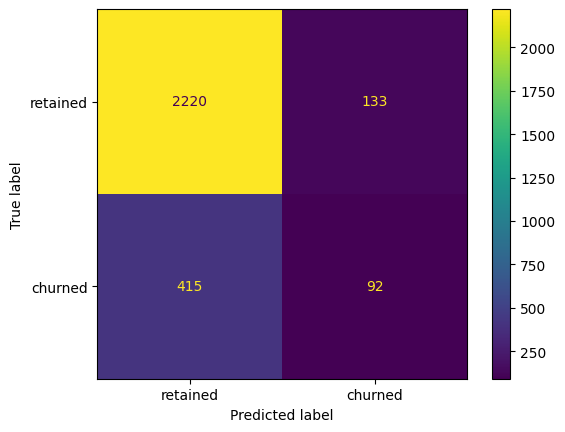

In [458]:
# Generating an array of values for the confusion matrix
cm = confusion_matrix(y_test, xgb_test_preds, labels = xgb_cv.classes_)

# Plotting the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix = cm,
                             display_labels = ["retained", "churned"])
disp.plot();

# Feature Importance

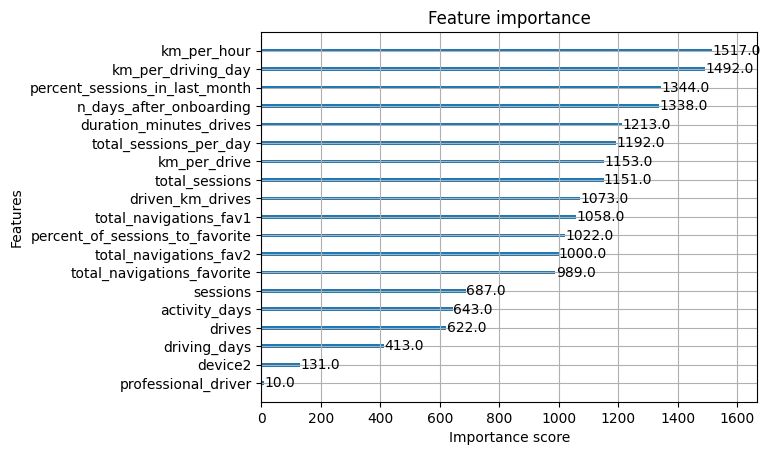

In [460]:
# Plotting the feature importance for the XGBoost model
plot_importance(xgb_cv.best_estimator_);
plt.savefig('feature_importance.png')

# Fourth Stage: Execute

Summary of Model Results
Logistic Regression

The logistic regression model exhibited poor performance, achieving an accuracy of 82%. The precision and recall scores of 52%, and 9% respectively indicate that the model does not suit the business adequately. The F1-score of 16% suggests that the model cannot correctly predict both positive and negative cases.

Tree-based Models

Both the random forest and the XGBoost models demonstranted improved performance compared to logistic regression. The random forest model achieved a recall of 13% on the validation set, and F1-score of 20%. While the XGBoost model achieved a recall of 16% and an F1-score of 22%, ultimately being selected as the champion model due to the nature of the business task.

Logistic Regression

Accuracy: 83% Precision: 52% Recall: 9% F1-score: 16%

Random Forest

Accuracy: 82% Precision: 48% Recall: 13% F1-score: 20%

XGBoost

Accuracy: 80% Precision: 38% Recall: 16% F1-score: 22%

Interpretation:

The XGBoost model outperformed both the Logistic Regression and the Random Forest models in the Recall and F1-score metrics. Which are the metrics most tailored to correctly identifying which users will churn. However, the performance is generally poor, and it is not considered to be a valuable predictive model.

## Conclusion & Recommendations
### Conclusion
The XGBoost model, despite its overall poor performance, outperformed the Logistic Regression and Random Forest models in terms of recall and F1-score, which are critical metrics for accurately predicting user churn. However, the model's performance is generally insufficient for practical use.

Recommendations

Given the limitations of the current models, Waze should consider the following recommendations:


Data Quality and Quantity: Evaluate the quality and sufficiency of the dataset. Explore the possibility of collecting additional data or refining the existing data to improve model performance.

Feature Engineering: Continue to experiment with feature engineering techniques to identify new or more informative features that could enhance model accuracy.

Model Selection and Hyperparameter Tuning: Explore other machine learning algorithms and techniques to potentially improve performance. Conduct thorough hyperparameter tuning for the XGBoost model to optimize its performance.

Optimal Decision Threshold: Finding an Optimal Decision Threshold may help improve the Recall and F1-score metrics, by sacrificing some of the precision and accuracy of the model.

External Data Sources: Explore the possibility of incorporating external data sources, such as user demographics or economic indicators, to provide additional insights and potentially improve model performance.

Next Steps

Waze should prioritize addressing the data quality and quantity issues identified in this analysis. Additionally, the team should continue to experiment with feature engineering and model selection techniques to improve the predictive capabilities of the churn model. The exploration of external data sources and finding an optimal decision threshold should also be considered as potential avenues for further development.